In [1]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: "%.3f" %x) #to restrict any float number to 3dp

In [2]:
#accessing my file from my google drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
#importing the dataset to be utilized
path= "/content/drive/MyDrive/Week 1  Foundations Python and Statistics/Melbourne_Housing.csv"
data=pd.read_csv(path)

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/

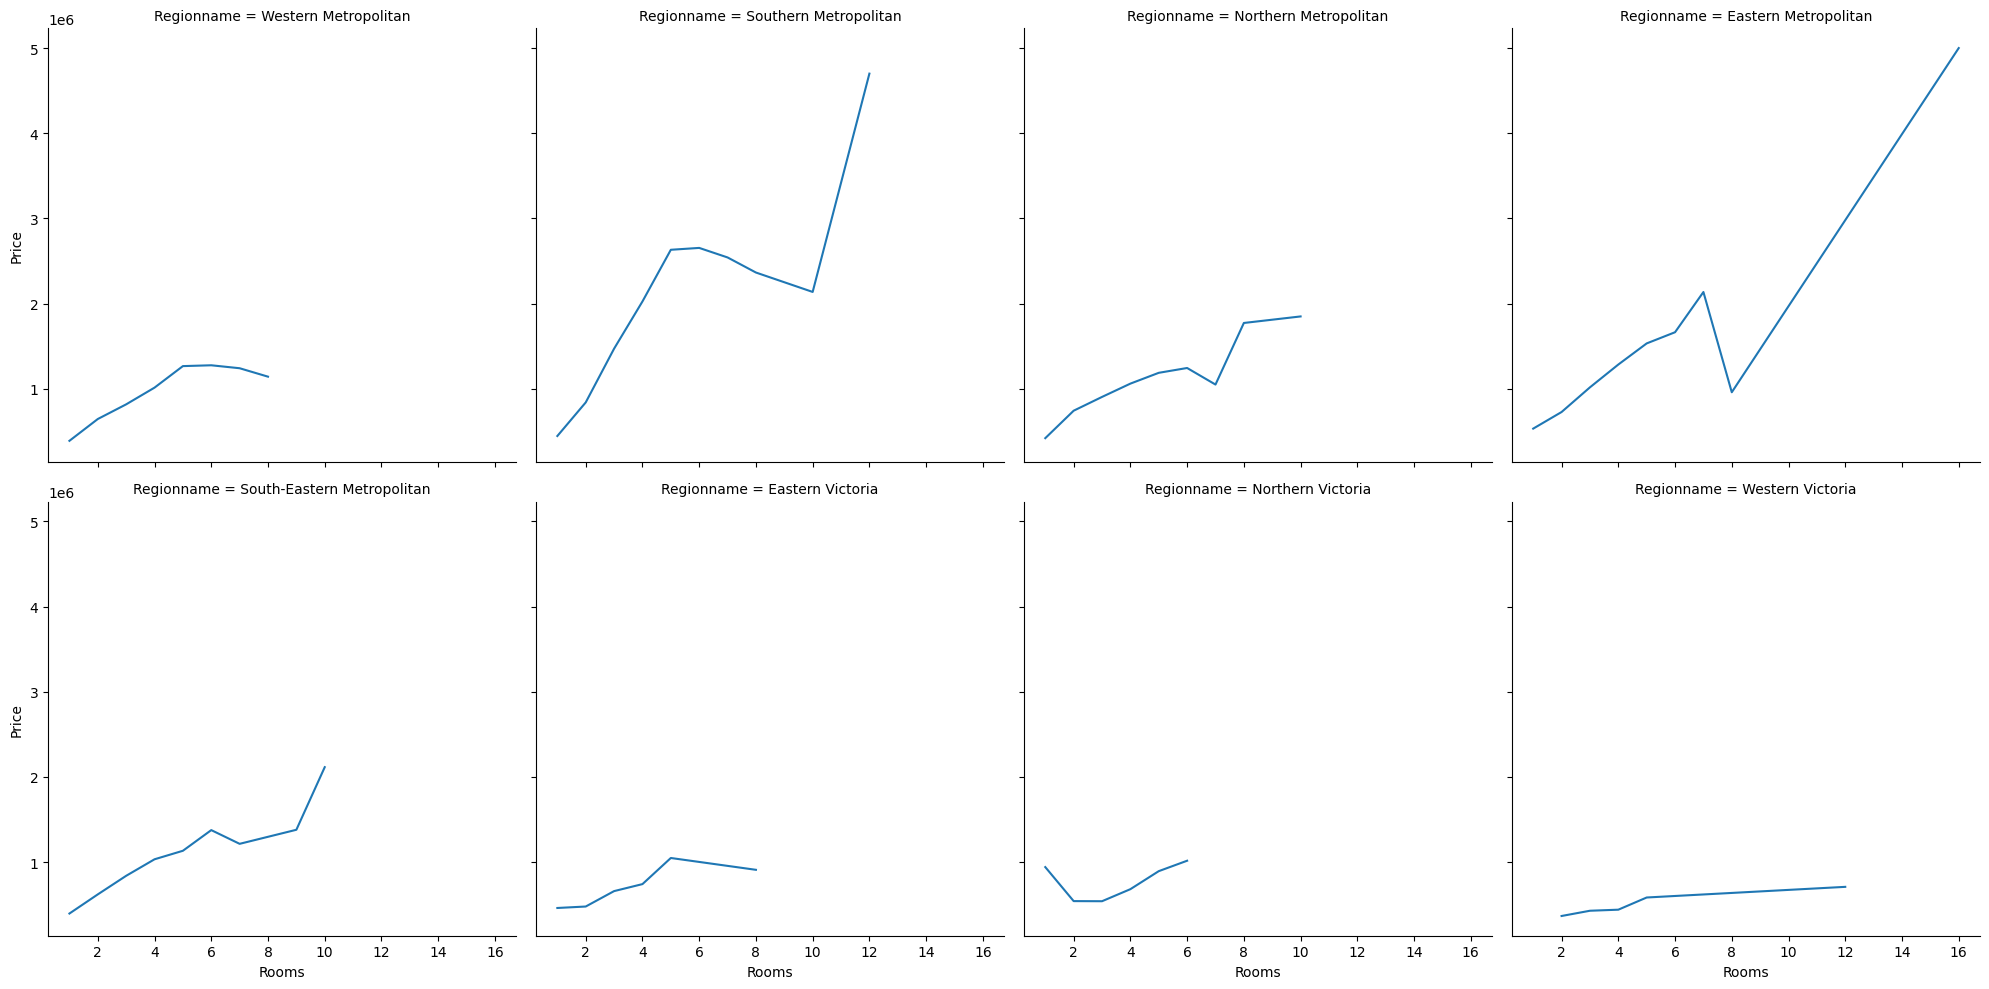

In [4]:
#sns.relplot is used to visualize any statistical relationship between quntitative variables. Why use relplot() instead of scatterplot()
#What is relplot made of
#kind that specifies the kind of plot to draw (scatter or line)
#ci - specifies the confidence interval
#col_wrap - specifies the number of columns in the grid

sns.relplot(
    data=data,
    x="Rooms",
    y="Price",
    col="Regionname",
    kind="line",
    ci=None,
    col_wrap=4,
)
plt.show()

#you can double click on the plot to zoom in

In [5]:
data.Regionname.value_counts(normalize=True)

,proportion
Regionname,
Southern Metropolitan,0.313
Northern Metropolitan,0.288
Western Metropolitan,0.214
Eastern Metropolitan,0.120
South-Eastern Metropolitan,0.049
Northern Victoria,0.006
Eastern Victoria,0.006
Western Victoria,0.003


**A properties price may vary depending on the property type.
E.g. Villa may cost higher than a duplex cos of its numerous amenities. Let's see the type of property is priced higher**

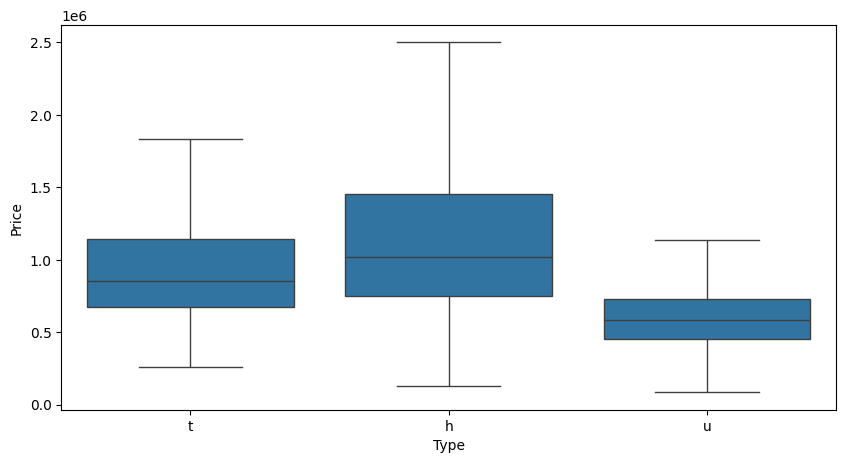

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data, x="Type", y="Price", showfliers=False) #this is to turn off outliers
plt.show()

Similarly the region of the property would also be integral in the price of selling the property.

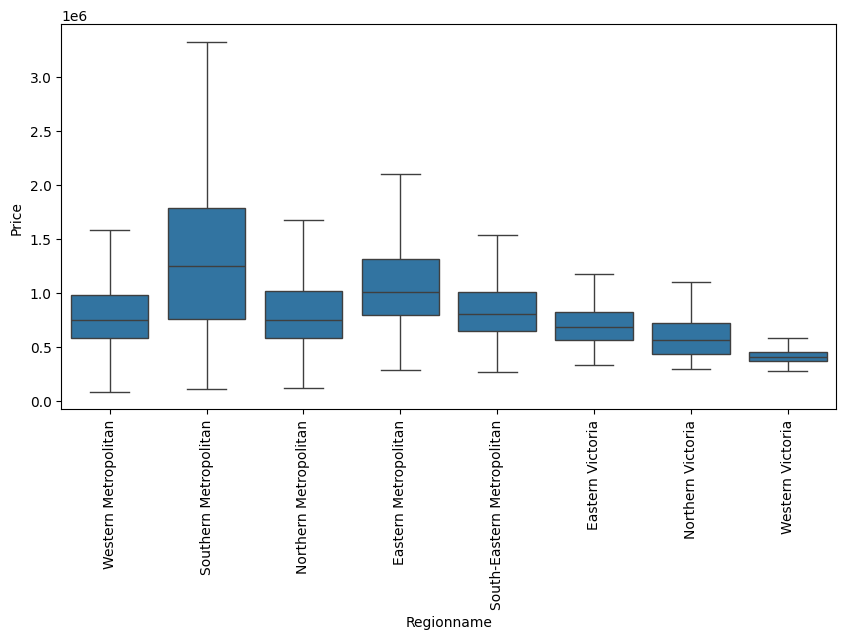

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=data, x="Regionname", y="Price", showfliers=False) #turning off outliers
plt.xticks(rotation=90)
plt.show()

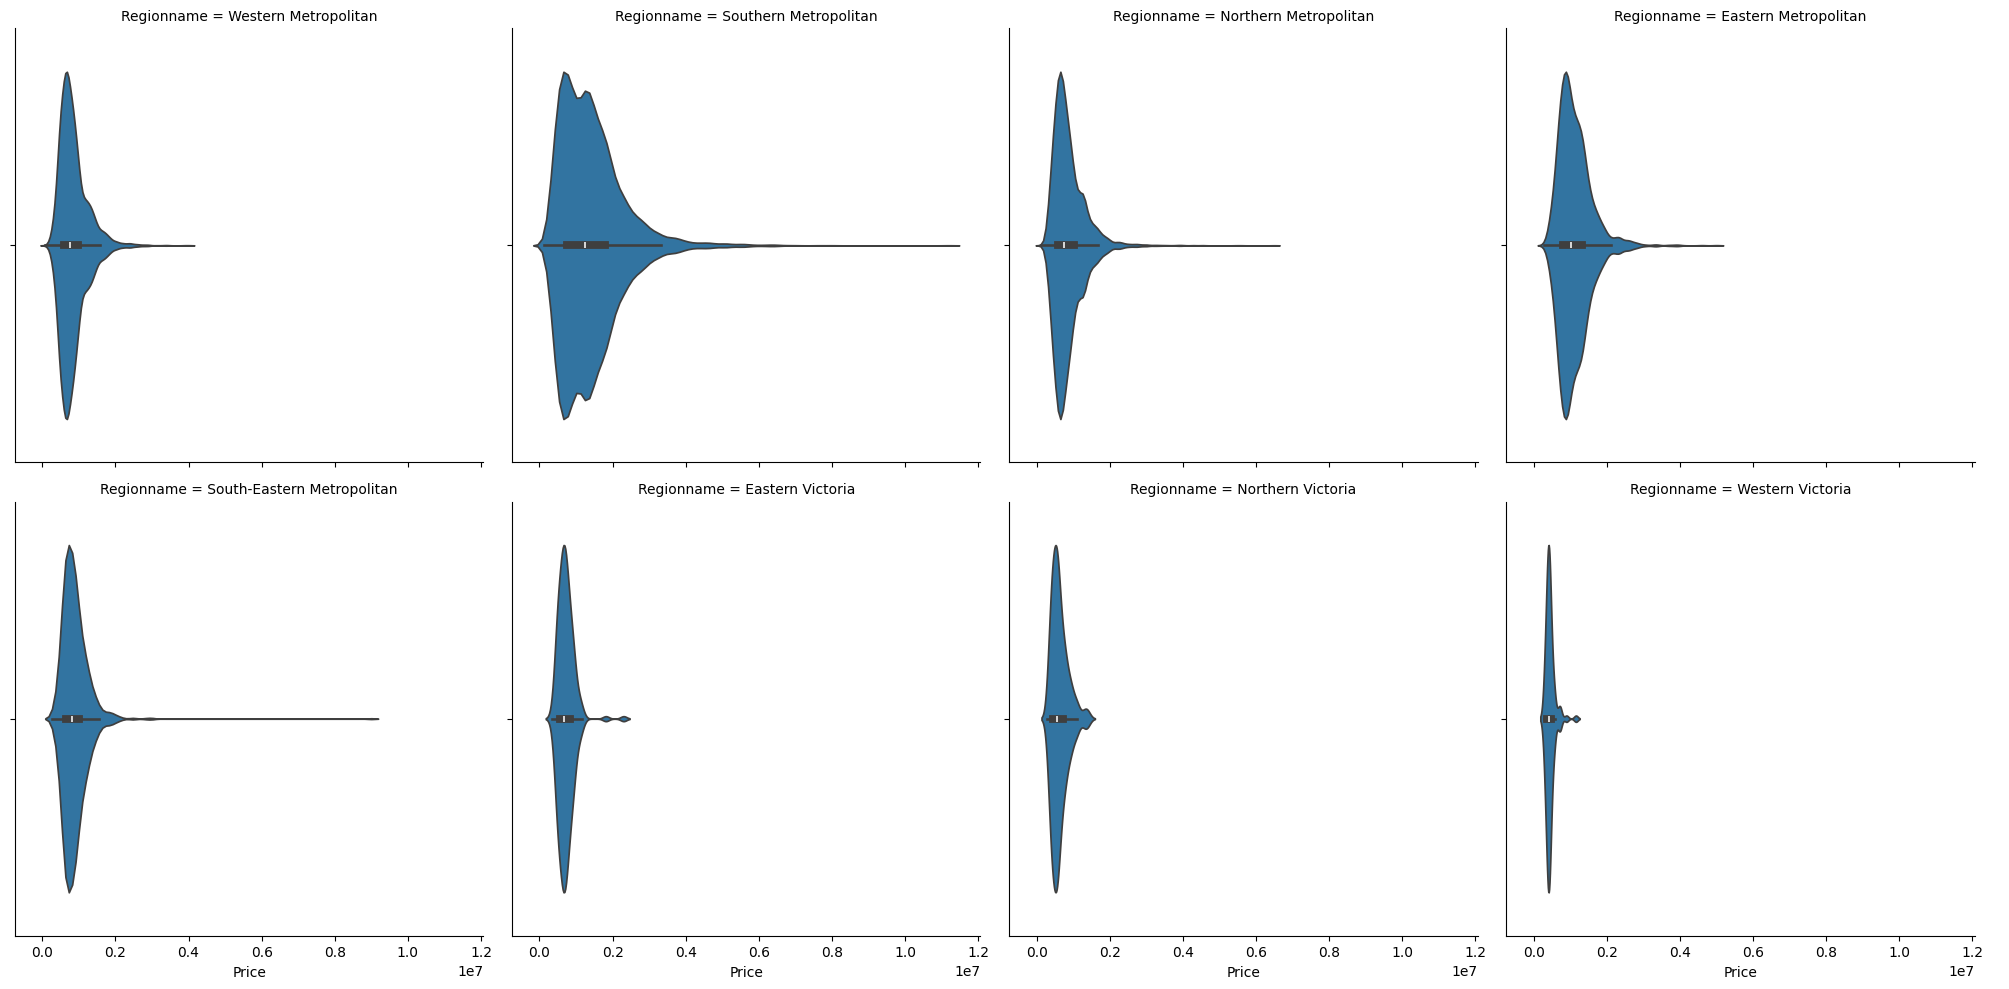

In [8]:
#Dispersion of Price in every region
sns.catplot(x="Price", col="Regionname", data=data, col_wrap=4, kind="violin")
plt.show()


**Missing Value Treatment**

In [9]:
data["Distance"].isnull()

,Distance
0,False
1,False
2,False
3,False
4,False
...,...
27109,False
27110,False
27111,False
27112,False


In [10]:
data["Distance"].isnull().sum()

1

In [11]:
#Extracting all the info of other variables where Distance is null
data.loc[data["Distance"].isnull() ==True]

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
9594,Fawkner Lot,3,h,Brad,06-01-2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Northern Metropolitan,962,616000


Data is missing for most of the other attributes as well

Checking to find more info using the name of the Suburb

In [12]:
data.loc[data["Suburb"]=="Fawkner Lot"]

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
9594,Fawkner Lot,3,h,Brad,06-01-2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Northern Metropolitan,962,616000


Dropping this row

In [13]:
data=data.drop(9590).reset_index(drop=True)

In [14]:
pd.DataFrame(
    {"Count": data.isnull().sum()[data.isnull().sum()>0],
     "Percentage": (data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])
     *100,
     }
)

,Count,Percentage
Distance,1,0.004
Postcode,1,0.004
Bedroom,6435,23.734
Bathroom,6441,23.756
Car,6816,25.139
Landsize,9240,34.080
BuildingArea,16570,61.115
YearBuilt,15128,55.796


In [15]:
data.loc[data["Bedroom"].isnull()==True, "Bathroom"]

,Bathroom
8,NaN
12,NaN
14,NaN
25,NaN
26,NaN
...,...
27099,NaN
27100,NaN
27101,NaN
27104,NaN


In [16]:
data.loc[data["Bedroom"].isnull()==True]

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
8,Altona North,4,h,hockingstuart,03-09-2016,11.100,3025.000,NaN,NaN,NaN,NaN,missing,NaN,Western Metropolitan,5132,857500
12,Ashburton,2,h,Marshall,03-09-2016,11.000,3147.000,NaN,NaN,NaN,NaN,inf,NaN,Southern Metropolitan,3052,1820000
14,Avondale Heights,4,h,Jellis,03-09-2016,10.500,3034.000,NaN,NaN,NaN,NaN,missing,NaN,Western Metropolitan,4502,1310000
25,Balwyn North,4,u,hockingstuart,03-09-2016,9.200,3104.000,NaN,NaN,NaN,NaN,missing,NaN,Southern Metropolitan,7809,1450000
26,Balwyn North,2,h,Fletchers,03-09-2016,9.200,3104.000,NaN,NaN,NaN,NaN,missing,NaN,Southern Metropolitan,7809,1305000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27099,Footscray,2,u,McGrath,30-09-2017,5.100,3011.000,NaN,NaN,NaN,NaN,NaN,NaN,Western Metropolitan,7570,455500
27100,Forest Hill,2,h,Fletchers,30-09-2017,15.400,3131.000,NaN,NaN,NaN,NaN,NaN,NaN,Eastern Metropolitan,4385,762000
27101,Glen Waverley,3,u,Ray,30-09-2017,16.700,3150.000,NaN,NaN,NaN,NaN,NaN,NaN,Eastern Metropolitan,15321,1100000
27104,Kingsbury,2,t,RW,30-09-2017,12.100,3083.000,NaN,NaN,NaN,NaN,NaN,NaN,Northern Metropolitan,1414,512000


From the dataframe above, it looks like when the bedroom is null, the data points in other columns are also missing. To affirm this, thecode below:

In [17]:
data.loc[data["Bedroom"].isnull()==True, "Bathroom"].value_counts(dropna=False)

,count
Bathroom,
NaN,6435


In [18]:
data.loc[data["Bedroom"].isnull()==True, "Car"].value_counts(dropna=False)

,count
Car,
NaN,6435


In [19]:
data.loc[data["Bathroom"].isnull()==True, "Landsize"].value_counts(dropna=False)

,count
Landsize,
NaN,6432
594.000,1
1111.000,1
446.000,1
375.000,1
338.000,1
250.000,1
259.000,1
549.000,1


In [20]:
data.loc[data["Bedroom"].isnull()==True, "BuildingArea"].value_counts(dropna=False)

,count
BuildingArea,
NaN,6430
missing,4
inf,1


In [21]:
data.loc[data["Bedroom"].isnull()==True, "YearBuilt"].value_counts(dropna=False)

,count
YearBuilt,
NaN,6435


In [22]:
data.loc[data["Bedroom"].isnull()==True, "Suburb"].value_counts(dropna=False)

,count
Suburb,
Reservoir,236
Bentleigh East,144
St Kilda,117
Glenroy,116
Richmond,111
...,...
St Helena,1
Scoresby,1
Seabrook,1


In [23]:
data["Suburb"].nunique()

345

In [24]:
data.loc[data["Bedroom"].isnull()==True, "Regionname"].value_counts(dropna=False)

,count
Regionname,
Southern Metropolitan,2201
Northern Metropolitan,1916
Western Metropolitan,1214
Eastern Metropolitan,728
South-Eastern Metropolitan,318
Eastern Victoria,26
Northern Victoria,25
Western Victoria,7


**Treating Missing VALUES for Befroom, Bathroom, and Car columns**

1) One of the approaches to treat the missing values would be to group the data on the basis of Region and Type of the property to get a better idea of the average number of bedrooms, bathrooms, and car parking spaces.

2)It is more likely that a property of certain type in a given region would have similar number of bedrooms, bathrooms, and car parking spaces.

In [25]:
#checking the average number of bedrooms, bathrooms, and car parking spaces in a region
data.groupby(["Regionname", "Type"])[["Bedroom", "Bathroom", "Car"]].mean()

Bedroom  Bathroom   Car
Regionname                 Type                         
Eastern Metropolitan       h       3.552     1.807 1.946
                           t       3.032     1.853 1.673
                           u       2.357     1.263 1.290
Eastern Victoria           h       3.560     1.881 2.098
                           u       2.667     1.000 1.333
Northern Metropolitan      h       3.106     1.468 1.685
                           t       2.567     1.620 1.362
                           u       1.878     1.160 1.093
Northern Victoria          h       3.496     1.892 2.146
                           u       3.000     2.000 2.000
South-Eastern Metropolitan h       3.476     1.713 2.094
                           t       2.887     1.849 1.679
                           u       2.260     1.205 1.342
Southern Metropolitan      h       3.383     1.840 1.883
                           t       3.024     2.012 1.780
                           u       1.939     1.191 1.135
Western Metropolitan       h       3.244     1.576 1.907
                           t       2.880     1.851 1.538
                           u       2.106     1.192 1.144
Western Victoria           h       3.379     1.448 2.060

#You can use the fillna() function and transform method of pandas to inpute the missing values

fillna() function - The fillna() function is used to fill NaN values using the provide input value.

Syntax of fillna():
data['column'].fillna(value=x)

transform() function- The transform function works on each value of a DataFrame and allows to execute a specified function on each value

Syntax of transform():
data.transform(func=function name)

*func - A function to be executed on the values of the DataFrame

In [26]:
data.groupby(["Regionname", "Type"])["Bedroom"].transform("mean")


,Bedroom
0,2.880
1,3.383
2,3.383
3,3.106
4,3.106
...,...
27108,3.476
27109,1.878
27110,3.106
27111,3.476


In [27]:
#Imputting missing values in Bedroom column
data["Bedroom"]=data["Bedroom"].fillna(
    value=data.groupby(["Regionname", "Type"])["Bedroom"].transform("mean")
)

In [28]:
#Imputting missing values in Bathroom column
data["Bathroom"]=data["Bedroom"].fillna(
    value=data.groupby(["Regionname", "Type"])["Bathroom"].transform("mean")
)

In [29]:
#Imputting missing values in Car column
data["Car"]=data["Car"].fillna(
    value=data.groupby(["Regionname", "Type"])["Car"].transform("mean")
)

In [30]:
#Checking if all the missing values were imputed in Bedroom, Bathroom, and Car columns
pd.DataFrame(
    {
        "Count": data.isnull().sum()[data.isnull().sum()>0],
        "Percentage": (data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])
    }
)

,Count,Percentage
Distance,1,0.000
Postcode,1,0.000
Landsize,9240,0.341
BuildingArea,16570,0.611
YearBuilt,15128,0.558


In [31]:
data.dtypes

,0
Suburb,object
Rooms,int64
Type,object
SellerG,object
Date,object
Distance,float64
Postcode,float64
Bedroom,float64
Bathroom,float64
Car,float64


Because we can't have floating numbers for some values like No of bedrooms, bathrrooms and car, so we turn the values to integer values

In [32]:
data["Bedroom"]=data["Bedroom"].astype(int)
data["Bathroom"]=data["Bathroom"].astype(int)
data["Car"]=data["Car"].astype(int)

#**Missing Values Treatment (Group medians, dropping)**

**Missing values of Total Space column**

We can create this feature again from the combination of Rooms, Bedroom, Bathroom, and Car as the missing values have now been imputed.

In [33]:
data.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
0,Airport West,3,t,Nelson,03-09-2016,13.500,3042.000,3,3,1,303.000,225,2016.000,Western Metropolitan,3464,840000
1,Albert Park,2,h,hockingstuart,03-09-2016,3.300,3206.000,2,2,0,120.000,82,1900.000,Southern Metropolitan,3280,1275000
2,Albert Park,2,h,Thomson,03-09-2016,3.300,3206.000,2,2,0,159.000,inf,NaN,Southern Metropolitan,3280,1455000
3,Alphington,4,h,Brace,03-09-2016,6.400,3078.000,3,3,4,853.000,263,1930.000,Northern Metropolitan,2211,2000000
4,Alphington,3,h,Jellis,03-09-2016,6.400,3078.000,3,3,2,208.000,inf,2013.000,Northern Metropolitan,2211,1110000


In [35]:
# #removing total space column
# data.drop("Total Space", axis=1, inplace=True)

# #creating new Total Space column
# data["Total_Space_New"]=(
#     data["Rooms"]+data["Bedroom"]+data["Bathroom"]+data["Car"]
# )
# data["Total_Space_New"]=data["Total_Space_New"].astype(int)


In [36]:
#checking if all the missing values were inputted in Bedroom, Bathroom, and Car Columns
pd.DataFrame(    {
        "Count": data.isnull().sum()[data.isnull().sum()>0],
        "Percentage":(data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])
        *100,
    })

,Count,Percentage
Distance,1,0.004
Postcode,1,0.004
Landsize,9240,34.080
BuildingArea,16570,61.115
YearBuilt,15128,55.796


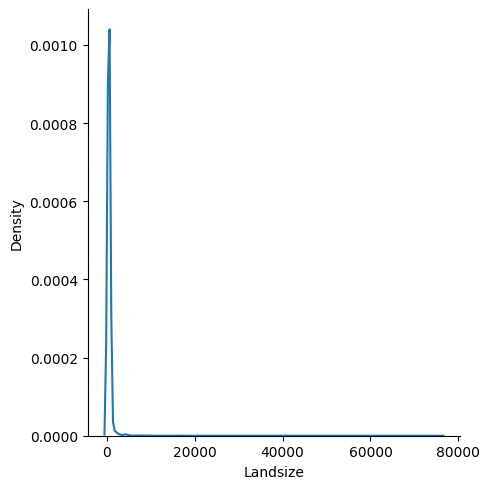

In [37]:
sns.displot(data=data, x="Landsize", kind="kde")
plt.show()

In [38]:
data.groupby(["Regionname", "Type"])[["Landsize"]].median()

Landsize
Regionname                 Type          
Eastern Metropolitan       h      693.500
                           t      236.000
                           u      208.000
Eastern Victoria           h      840.000
                           u      230.000
Northern Metropolitan      h      482.000
                           t      145.000
                           u       50.000
Northern Victoria          h      737.500
                           u      315.000
South-Eastern Metropolitan h      632.000
                           t      248.000
                           u      210.000
Southern Metropolitan      h      593.000
                           t      267.000
                           u       50.000
Western Metropolitan       h      537.000
                           t      200.000
                           u       80.000
Western Victoria           h      603.000

We can utilize data which is not null to proceed with the analysis which allow us to preserve the data which is not missing

We can drop these columns from the data but it will lead to loss of data points from the data

In [39]:
#Removing 61% null values from the building area column
new_data=data[data["BuildingArea"].notnull()]
new_data.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
0,Airport West,3,t,Nelson,03-09-2016,13.500,3042.000,3,3,1,303.000,225,2016.000,Western Metropolitan,3464,840000
1,Albert Park,2,h,hockingstuart,03-09-2016,3.300,3206.000,2,2,0,120.000,82,1900.000,Southern Metropolitan,3280,1275000
2,Albert Park,2,h,Thomson,03-09-2016,3.300,3206.000,2,2,0,159.000,inf,NaN,Southern Metropolitan,3280,1455000
3,Alphington,4,h,Brace,03-09-2016,6.400,3078.000,3,3,4,853.000,263,1930.000,Northern Metropolitan,2211,2000000
4,Alphington,3,h,Jellis,03-09-2016,6.400,3078.000,3,3,2,208.000,inf,2013.000,Northern Metropolitan,2211,1110000


In [40]:
data.shape

(27113, 16)

In [41]:
new_data.shape

(10543, 16)

In [43]:
#dropping columns
data=data.drop(["BuildingArea","YearBuilt"], axis=1)

In [44]:
data.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,Regionname,Propertycount,Price
0,Airport West,3,t,Nelson,03-09-2016,13.500,3042.000,3,3,1,303.000,Western Metropolitan,3464,840000
1,Albert Park,2,h,hockingstuart,03-09-2016,3.300,3206.000,2,2,0,120.000,Southern Metropolitan,3280,1275000
2,Albert Park,2,h,Thomson,03-09-2016,3.300,3206.000,2,2,0,159.000,Southern Metropolitan,3280,1455000
3,Alphington,4,h,Brace,03-09-2016,6.400,3078.000,3,3,4,853.000,Northern Metropolitan,2211,2000000
4,Alphington,3,h,Jellis,03-09-2016,6.400,3078.000,3,3,2,208.000,Northern Metropolitan,2211,1110000


In [45]:
#saving the dataset with all missing values already treated
data.to_csv(
    "/content/drive/MyDrive/Week 1  Foundations Python and Statistics/Melbourne_HousingNomissing.csv", index=False
)